In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.stats import zscore

In [11]:
features_df.columns = [
    "image_name",
    "label",
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "extent",
    "major_axis_length",
    "minor_axis_length",
    "convex_area",
    "equivalent_diameter"
]

In [2]:
PROJECT_DIR = r"D:\hiPSC_Morphology_Project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")

PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")

RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(PROJECT_DIR)

D:\hiPSC_Morphology_Project


In [3]:
FEATURES_CSV = os.path.join(PROCESSED_DIR, "features.csv")

features_df = pd.read_csv(FEATURES_CSV)

print("Dataset loaded successfully!")

print(features_df.shape)

Dataset loaded successfully!
(69713, 11)


In [4]:
features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69713 entries, 0 to 69712
Data columns (total 11 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   00031b2f_3500000969_10X_20170613_11_27(10)-Scene-10-F8-F08_seg.tiff  69713 non-null  str    
 1   1                                                                    69713 non-null  int64  
 2   4420.0                                                               69713 non-null  float64
 3   306.8061325481597                                                    69713 non-null  float64
 4   0.8787382954447599                                                   69713 non-null  float64
 5   0.8550976978138906                                                   69713 non-null  float64
 6   0.5328511151295962                                                   69713 non-null  float64
 7   113.10821751146

In [5]:
print(features_df.isnull().sum())

00031b2f_3500000969_10X_20170613_11_27(10)-Scene-10-F8-F08_seg.tiff    0
1                                                                      0
4420.0                                                                 0
306.8061325481597                                                      0
0.8787382954447599                                                     0
0.8550976978138906                                                     0
0.5328511151295962                                                     0
113.10821751146602                                                     0
53.98699276722581                                                      0
5169.0                                                                 0
75.01812306189365                                                      0
dtype: int64


In [6]:
features_df.describe()

,1,4420.0,306.8061325481597,0.8787382954447599,0.8550976978138906,0.5328511151295962,113.10821751146602,53.98699276722581,5169.0,75.01812306189365
count,69713.000000,6.971300e+04,69713.000000,69713.000000,69713.000000,69713.000000,69713.000000,69713.000000,6.971300e+04,69713.000000
mean,17.707644,1.468087e+04,519.319711,0.759546,0.860255,0.575307,139.493956,76.905566,2.262142e+04,89.794971
std,12.280532,6.133197e+04,1178.745366,0.151666,0.127673,0.124331,179.925130,105.541132,9.652311e+04,103.098404
min,1.000000,3.600000e+02,68.769553,0.003023,0.084114,0.030357,21.799268,17.284340,3.730000e+02,21.409489
25%,8.000000,1.243000e+03,147.095454,0.672699,0.798718,0.492560,51.074268,31.978366,1.352000e+03,39.782367
50%,16.000000,2.694000e+03,228.835570,0.790644,0.916203,0.598428,80.847446,46.029927,3.018000e+03,58.567118
75%,25.000000,7.711000e+03,431.730014,0.876929,0.955172,0.670996,148.952880,78.882061,9.363000e+03,99.085570
max,75.000000,1.318639e+06,27042.224115,0.999048,0.998875,0.894467,1745.944390,1469.755886,1.522806e+06,1295.740452


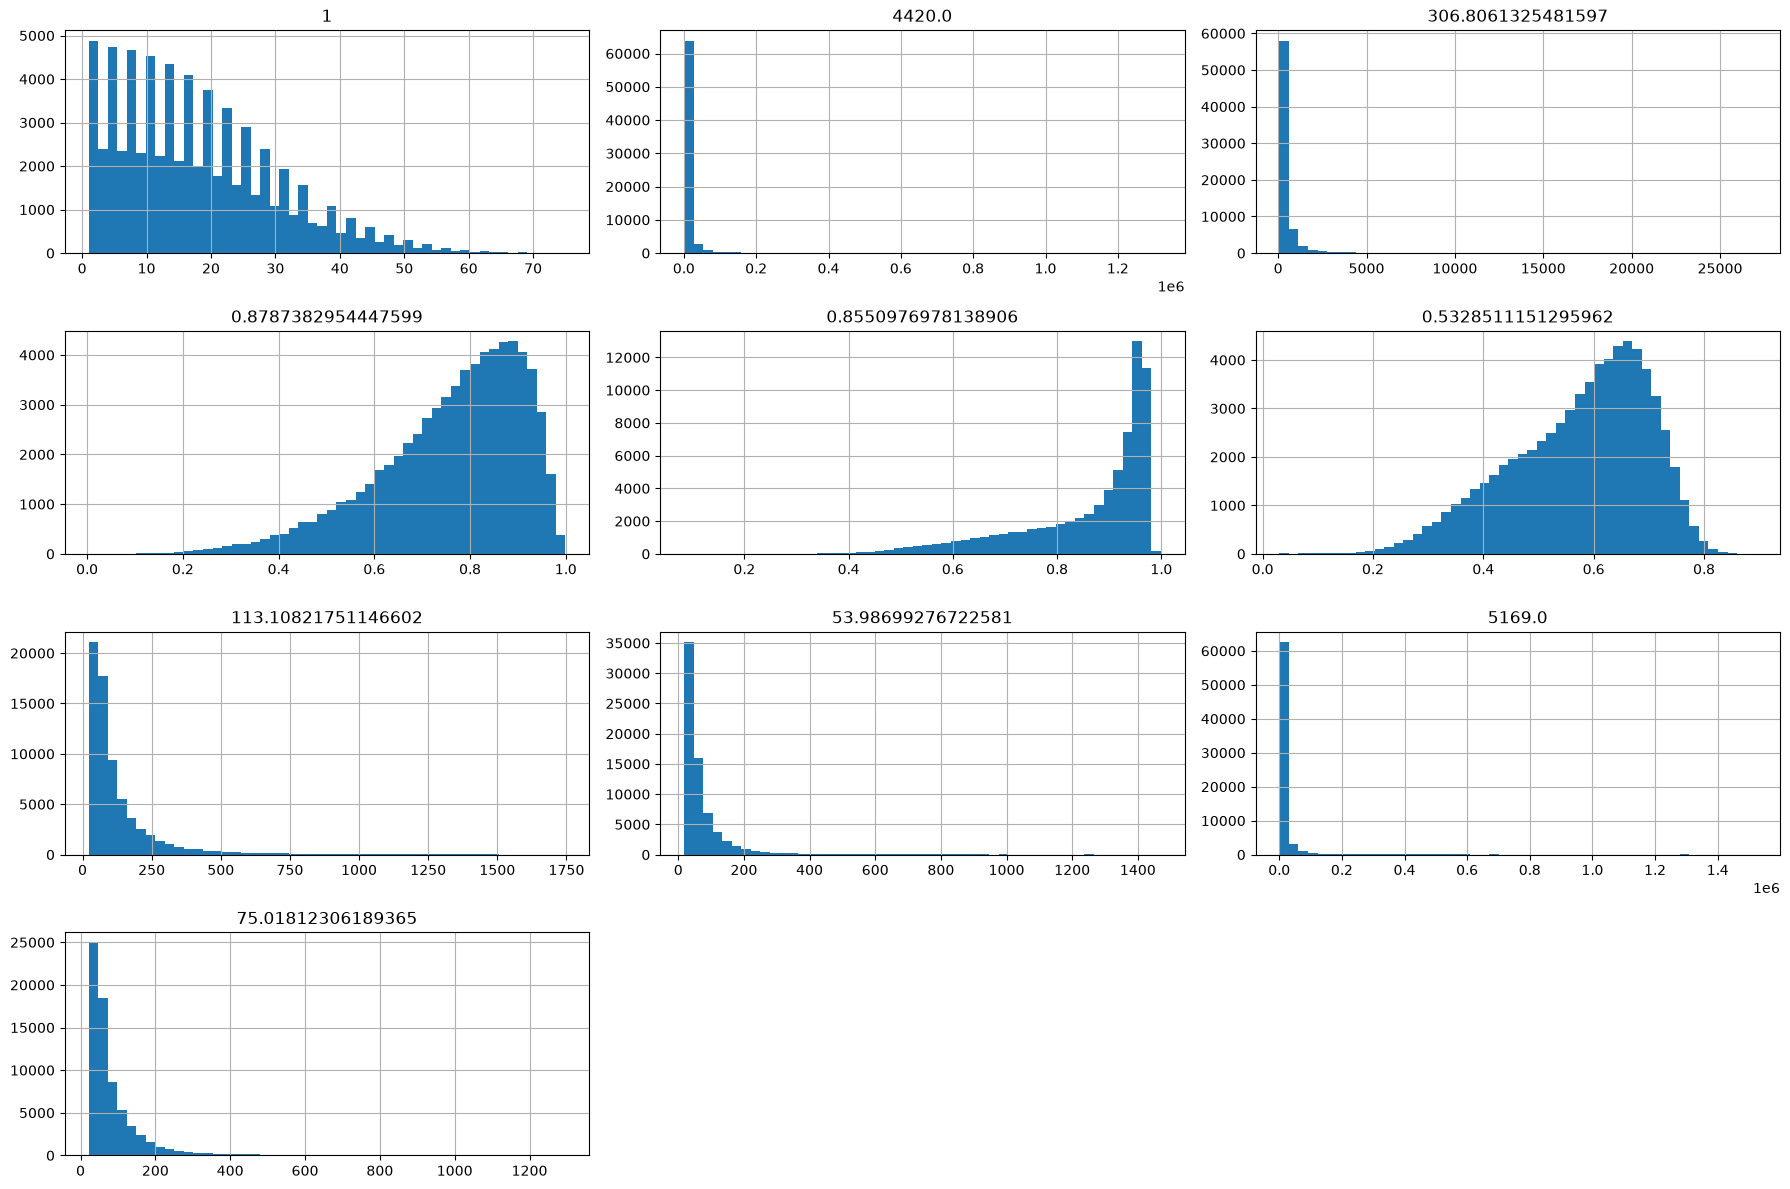

In [7]:
features_df.hist(figsize=(18, 12), bins=50)

plt.tight_layout()

plt.show()

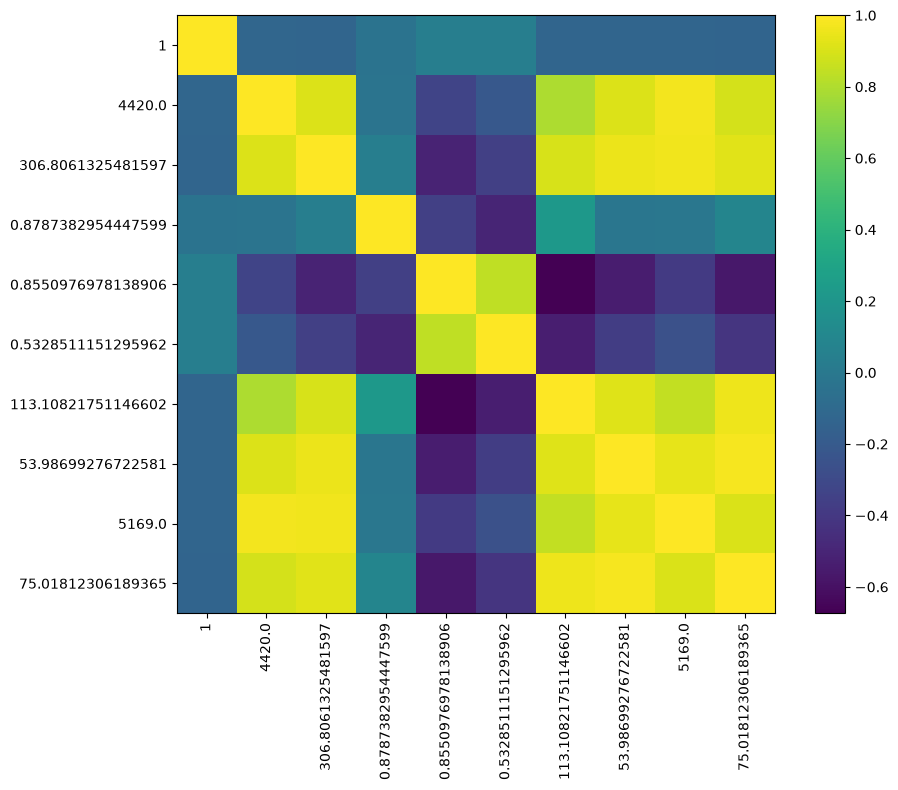

In [26]:
correlation = features_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(correlation, interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.tight_layout()

plt.show()

In [14]:
colonies_per_image = features_df.groupby("image_name").size()

print(colonies_per_image.describe())

count    2474.000000
mean       28.178658
std        13.258862
min         1.000000
25%        19.000000
50%        28.000000
75%        37.000000
max        75.000000
dtype: float64


In [13]:
features_df.nlargest(10, "area")

,image_name,label,area,perimeter,eccentricity,solidity,extent,major_axis_length,minor_axis_length,convex_area,equivalent_diameter
14988,343e8279_3500002669_10X_20190118_C9_seg.tiff,1,1318639.0,4834.849348,0.170245,0.990424,0.779061,1306.803442,1287.726487,1331389.0,1295.740452
30949,6ec5dc28_3500001126_10X_20170728_17_65(10)-Sce...,1,1303032.0,4264.148771,0.003023,0.998875,0.786680,1288.052775,1288.046890,1304500.0,1288.049638
52378,bad28547_3500001449_10X_20171023_24_80-Scene-0...,1,1301847.0,4434.138669,0.148095,0.991306,0.778687,1295.194338,1280.912433,1313264.0,1287.463818
51228,b59f7952_3500003121_10X_20190607_D3_seg.tiff,1,1300828.0,5194.958041,0.286708,0.975797,0.766180,1319.991795,1264.575792,1333093.0,1286.959848
18022,3eaae56f_3500000971_10X_20170614_11_27-Scene-0...,1,1295007.0,4280.959954,0.168270,0.997896,0.779411,1293.394479,1274.951958,1297738.0,1284.077148
54052,c05f7945_3500000971_10X_20170614_11_27(6)-Scen...,1,1293966.0,4513.073698,0.245645,0.982433,0.769206,1306.692179,1266.654915,1317103.0,1283.560938
42105,95a2d093_3500000981_10X_20170616_11_27(5)-Scen...,1,1293914.0,4428.646245,0.218038,0.985645,0.773942,1301.165199,1269.859461,1312759.0,1283.535146
61118,da56e069_3500001126_10X_20170728_17_65-Scene-0...,1,1291834.0,4472.499059,0.235913,0.982782,0.772698,1303.947581,1267.142644,1314467.0,1282.503074
50983,b44a4ac4_3500003121_10X_20190607_D4_seg.tiff,1,1283943.0,5651.889066,0.306323,0.970073,0.767398,1317.398902,1254.068513,1323553.0,1278.580072
48033,aa8c30d1_3500001079_10X_20170717_17_65(3)-Scen...,1,1261447.0,4705.186397,0.338932,0.964680,0.756862,1313.475177,1235.731773,1307633.0,1267.329556


In [ ]:
print(features_df.columns.tolist())

In [9]:
features_df.head()

,00031b2f_3500000969_10X_20170613_11_27(10)-Scene-10-F8-F08_seg.tiff,1,4420.0,306.8061325481597,0.8787382954447599,0.8550976978138906,0.5328511151295962,113.10821751146602,53.98699276722581,5169.0,75.01812306189365
0,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,2,1605.0,161.480231,0.778643,0.951393,0.597098,57.766271,36.246447,1687.0,45.205635
1,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,3,1216.0,136.781746,0.271627,0.970471,0.643386,41.052407,39.508946,1253.0,39.347926
2,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,4,549.0,91.112698,0.779800,0.973404,0.769986,33.845157,21.188053,564.0,26.438769
3,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,5,1412.0,146.994949,0.672782,0.957938,0.626442,49.652234,36.734742,1474.0,42.400640
4,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,6,1399.0,182.130988,0.721516,0.858282,0.471520,56.147844,38.876645,1630.0,42.205001


In [10]:
features_df = pd.read_csv(FEATURES_CSV, header=None)

print(features_df.shape)

(69714, 11)


In [12]:
features_df.head()

,image_name,label,area,perimeter,eccentricity,solidity,extent,major_axis_length,minor_axis_length,convex_area,equivalent_diameter
0,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,1,4420.0,306.806133,0.878738,0.855098,0.532851,113.108218,53.986993,5169.0,75.018123
1,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,2,1605.0,161.480231,0.778643,0.951393,0.597098,57.766271,36.246447,1687.0,45.205635
2,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,3,1216.0,136.781746,0.271627,0.970471,0.643386,41.052407,39.508946,1253.0,39.347926
3,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,4,549.0,91.112698,0.779800,0.973404,0.769986,33.845157,21.188053,564.0,26.438769
4,00031b2f_3500000969_10X_20170613_11_27(10)-Sce...,5,1412.0,146.994949,0.672782,0.957938,0.626442,49.652234,36.734742,1474.0,42.400640


In [15]:
features_df.to_csv(FEATURES_CSV, index=False)

In [16]:
print("Total colonies:", len(features_df))
print("Total images:", features_df["image_name"].nunique())

print("\nColumns:")
print(features_df.columns.tolist())

Total colonies: 69714
Total images: 2474

Columns:
['image_name', 'label', 'area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'major_axis_length', 'minor_axis_length', 'convex_area', 'equivalent_diameter']


In [17]:
log_df = pd.read_csv(os.path.join(PROCESSED_DIR, "processing_log.csv"))

print(log_df.head())
print(log_df.columns)

                                          image_name  colonies_found  \
0  00031b2f_3500000969_10X_20170613_11_27(10)-Sce...              24   
1  001bf60f_3500001005_10X_20170623_11_27(4)-Scen...              48   
2  002a7044_3500001388_10X_20171009_23_20-Scene-0...              26   
3  003201bf_3500000778_10X_20170331_11_27(4)-Scen...              29   
4  0035d714_3500001319_10X_20170922_24_80-Scene-0...              12   

   processing_time_seconds   status  
0                     1.04  Success  
1                     1.07  Success  
2                     1.92  Success  
3                     0.55  Success  
4                     3.09  Success  
Index(['image_name', 'colonies_found', 'processing_time_seconds', 'status'], dtype='str')


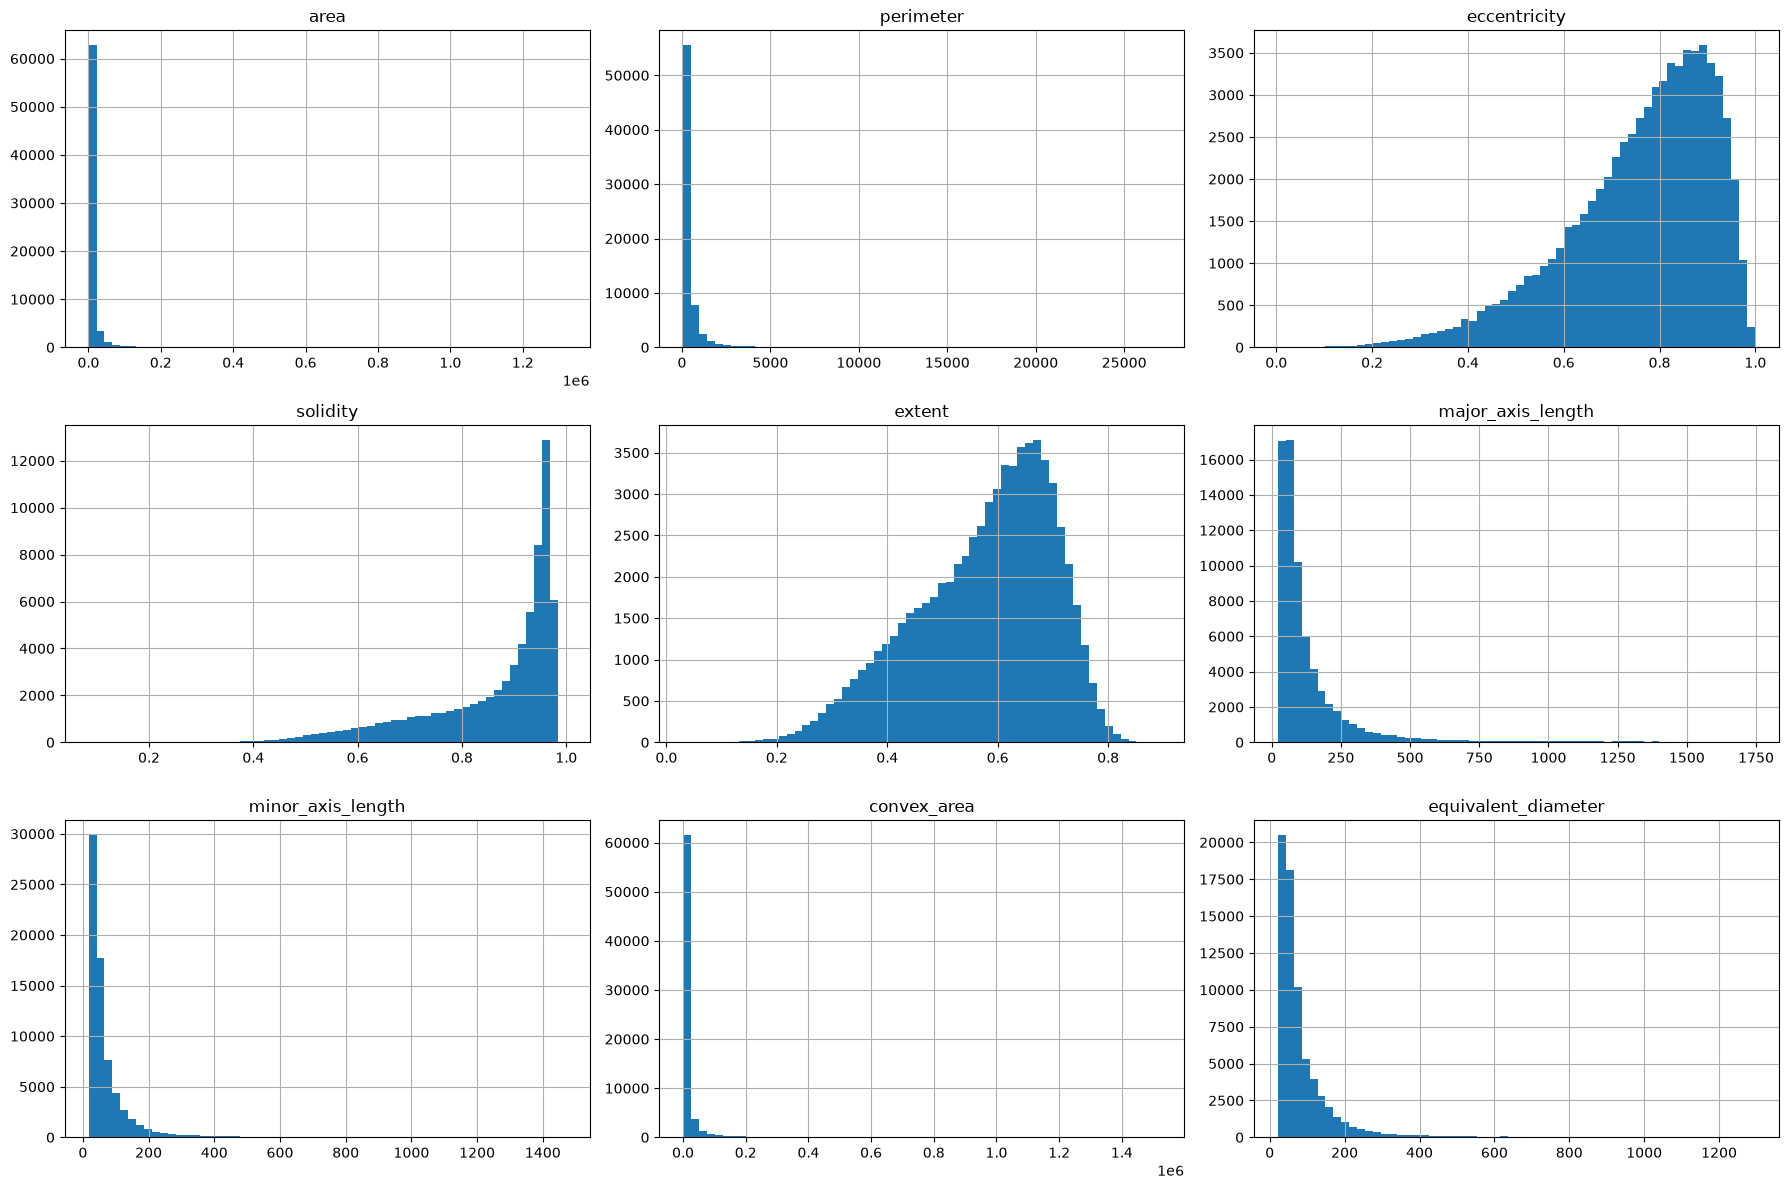

In [18]:
features = [
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "extent",
    "major_axis_length",
    "minor_axis_length",
    "convex_area",
    "equivalent_diameter"
]

features_df[features].hist(
    figsize=(18, 12),
    bins=60
)

plt.tight_layout()

plt.show()

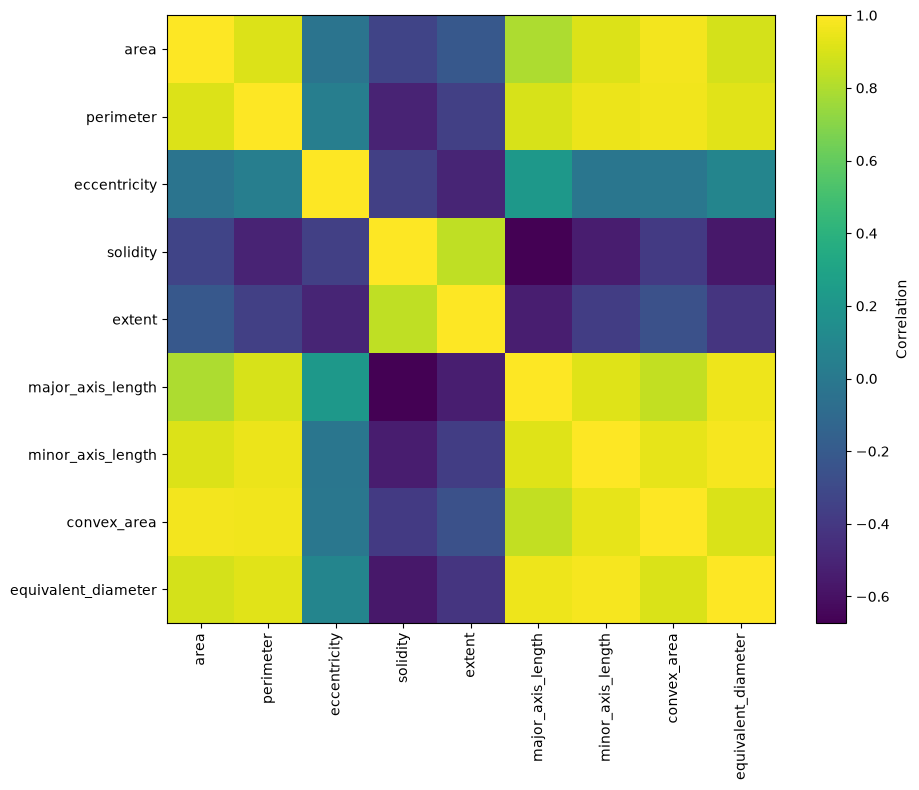

In [19]:
corr = features_df[features].corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(range(len(features)), features, rotation=90)

plt.yticks(range(len(features)), features)

plt.colorbar(label="Correlation")

plt.tight_layout()

plt.show()

In [21]:
print((log_df["colonies_found"] == 0).sum())

print(log_df["colonies_found"].describe())

412
count    2890.000000
mean       24.121107
std        15.761677
min        -1.000000
25%        13.000000
50%        25.000000
75%        35.000000
max        75.000000
Name: colonies_found, dtype: float64
